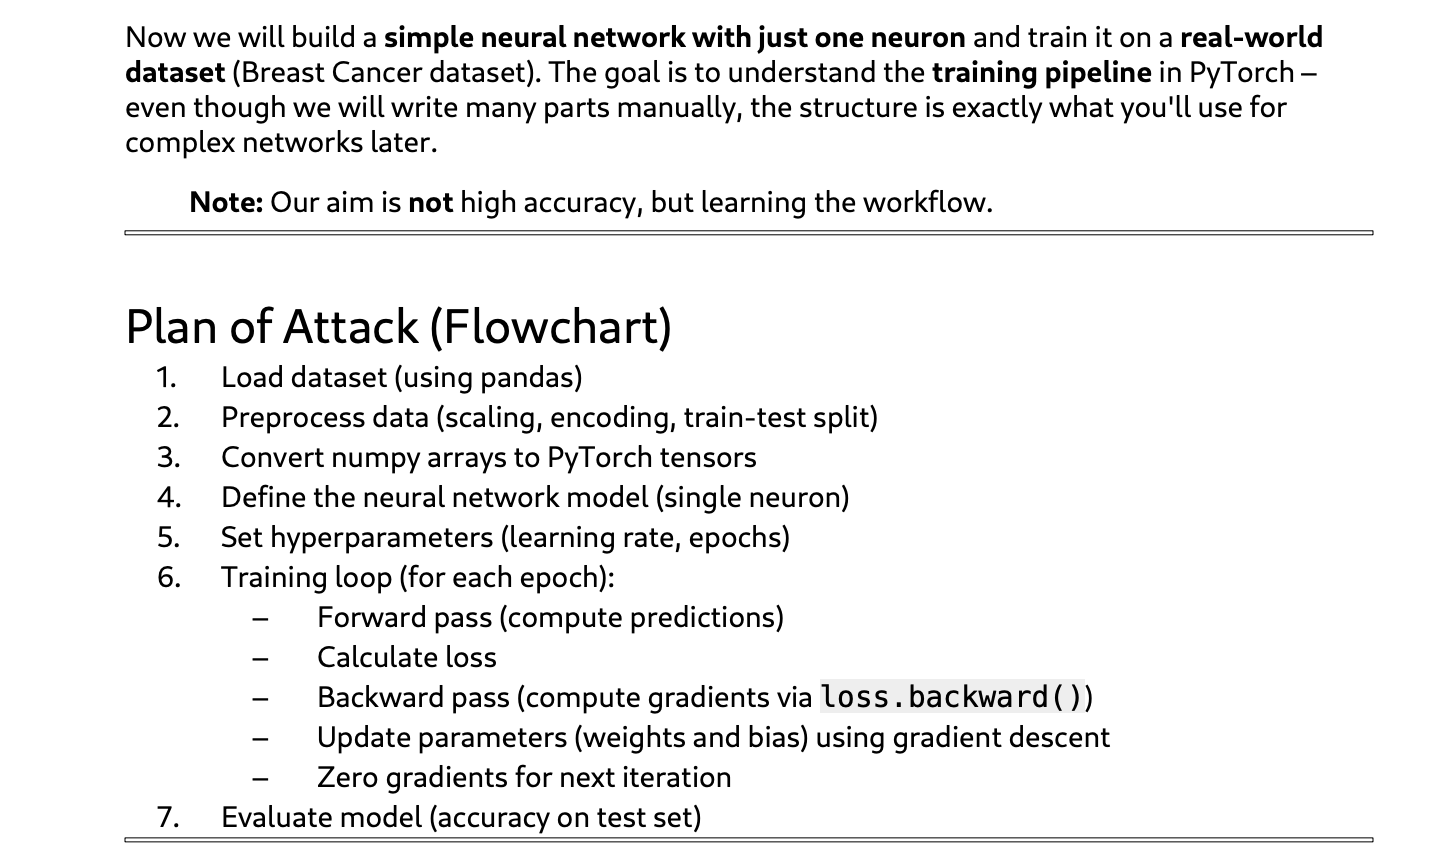

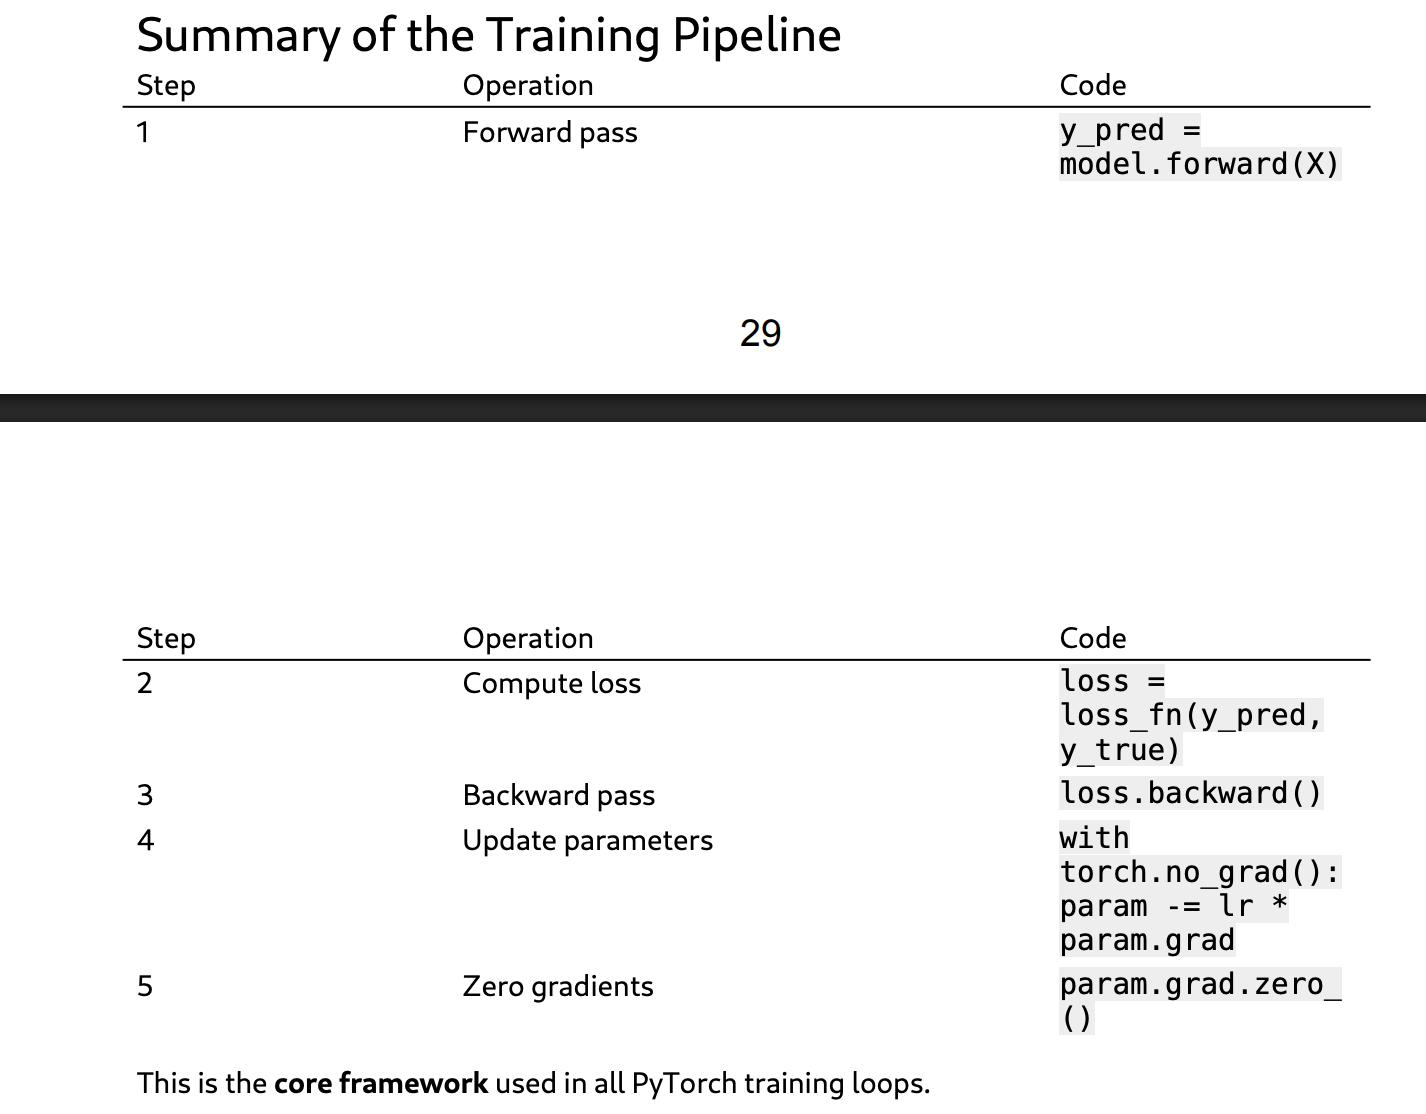

## Step 1: Load and Preprocess Data

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
import torch

####  Load data

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.shape

(569, 33)

In [5]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

####  Drop unnecessary columns

In [6]:

df.drop(["id","Unnamed: 32"],axis="columns",inplace=True)
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

#### Split features and target

In [8]:
X=df.drop(["diagnosis"],axis="columns").values
y=df["diagnosis"].values

####  Train-test split

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#### Scale features (important for neural networks)

In [10]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [11]:
X_train

array([[-1.44075296, -0.43531947, -1.36208497, ...,  0.9320124 ,
         2.09724217,  1.88645014],
       [ 1.97409619,  1.73302577,  2.09167167, ...,  2.6989469 ,
         1.89116053,  2.49783848],
       [-1.39998202, -1.24962228, -1.34520926, ..., -0.97023893,
         0.59760192,  0.0578942 ],
       ...,
       [ 0.04880192, -0.55500086, -0.06512547, ..., -1.23903365,
        -0.70863864, -1.27145475],
       [-0.03896885,  0.10207345, -0.03137406, ...,  1.05001236,
         0.43432185,  1.21336207],
       [-0.54860557,  0.31327591, -0.60350155, ..., -0.61102866,
        -0.3345212 , -0.84628745]], shape=(455, 30))

In [12]:
X_test

array([[-0.46649743, -0.13728933, -0.44421138, ..., -0.19435087,
         0.17275669,  0.20372995],
       [ 1.36536344,  0.49866473,  1.30551088, ...,  0.99177862,
        -0.561211  , -1.00838949],
       [ 0.38006578,  0.06921974,  0.40410139, ...,  0.57035018,
        -0.10783139, -0.20629287],
       ...,
       [-0.73547237, -0.99852603, -0.74138839, ..., -0.27741059,
        -0.3820785 , -0.32408328],
       [ 0.02898271,  2.0334026 ,  0.0274851 , ..., -0.49027026,
        -1.60905688, -0.33137507],
       [ 1.87216885,  2.80077153,  1.80354992, ...,  0.7925579 ,
        -0.05868885, -0.09467243]], shape=(114, 30))

In [13]:
y_train

array(['B', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'M', 'M',
       'B', 'B', 'M', 'M', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'M',
       'B', 'M', 'B', 'B', 'M', 'B', 'M', 'M', 'M', 'B', 'M', 'B', 'B',
       'B', 'B', 'M', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'B',
       'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'B',
       'B', 'B', 'B', 'B', 'M', 'M', 'M', 'B', 'B', 'M', 'B', 'M', 'B',
       'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'M',
       'M', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'B',
       'B', 'B', 'M', 'B', 'M', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'B',
       'B', 'B', 'B', 'M', 'M', 'M', 'B', 'B', 'M', 'B', 'B', 'M', 'B',
       'M', 'B', 'M', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'B',
       'M', 'B', 'M', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'M',
       'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B',
       'B', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'M', 'B

#### Encode labels (M = malignant, B = benign) to 1 and 0

In [14]:
encoder=LabelEncoder()
y_train=encoder.fit_transform(y_train)
y_test=encoder.transform(y_test)

In [15]:
y_train

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,

#### Convert numpy arrays to PyTorch tensors

In [16]:
X_train_tensor=torch.from_numpy(X_train).float()
X_test_tensor=torch.from_numpy(X_test).float()
y_train_tensor=torch.from_numpy(y_train).float()
y_test_tensor=torch.from_numpy(y_test).float()

In [17]:
X_train_tensor.shape # 30 features

torch.Size([455, 30])

In [18]:
y_train_tensor.shape

torch.Size([455])

## Step 2: Define the Neural Network (Single Neuron)

We create a class MySimpleNeuralNetwork. The neuron has:
- 30 weights (one per input feature)
- 1 bias
We initialize weights randomly, bias to zero. Both require gradients (requires_grad=True).

In [19]:
torch.rand(size=(2,3))

tensor([[0.1632, 0.0182, 0.8060],
        [0.1293, 0.4830, 0.8304]])

In [20]:
class MySimpleNeuralNetwork:
    def __init__(self,X):
        #Number of features (30)
        self.weights=torch.rand(size=(X.shape[1],1),dtype=torch.float32,requires_grad=True)
        self.bias=torch.zeros(1,dtype=torch.float32,requires_grad=True)
    
    def forward(self,X):
        # Linear combination: z = X * w + b
        z=torch.matmul(X,self.weights)+self.bias
        # Sigmoid activation for binary classification
        y_pred=torch.sigmoid(z)
        return y_pred
    
    def loss_function(self,y_pred,y_true):
        #Clamp predictions to avoid log(0)
        epsilon=1e-7
        y_pred=torch.clamp(y_pred,min=epsilon,max=1-epsilon)

        #calculate binary cross entropy loss
        loss=-torch.mean(y_true*torch.log(y_pred)+(1-y_true)*torch.log(1-y_pred))
        return loss


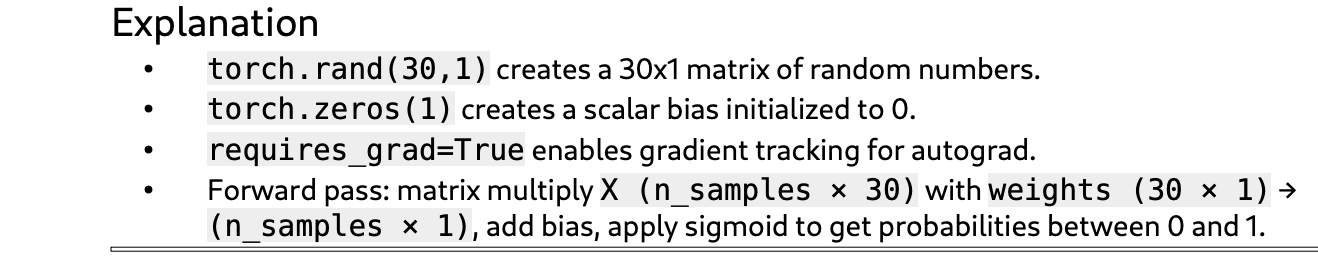

## Step 3: Hyperparameters

In [21]:
learning_rate=0.1
epochs=25

## Step 4: Create Model Instance

In [22]:
model=MySimpleNeuralNetwork(X_train_tensor)
#Check initial weights and bias:
print(model.weights.shape) # torch.Size([30, 1])
print(model.bias) # tensor([0.], dtype=torch.float64,requires_grad=True)

torch.Size([30, 1])
tensor([0.], requires_grad=True)


## Step 6: Training Pipeline

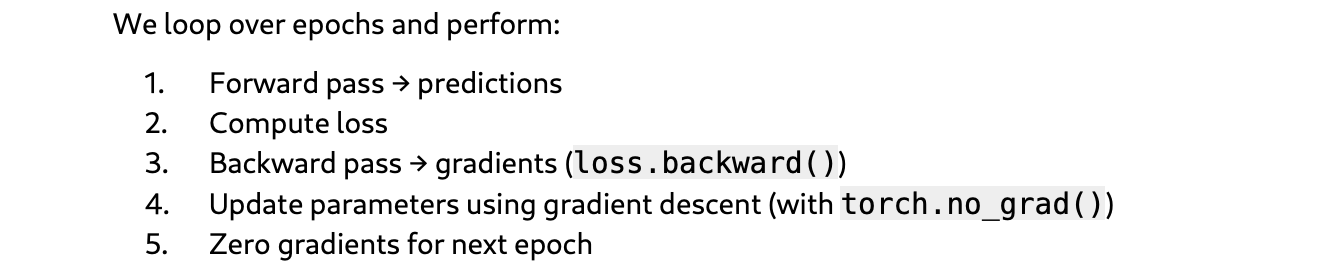

In [24]:
# Create model
model = MySimpleNeuralNetwork(X_train_tensor)

# Define loop
for epoch in range(epochs):
    # 1. Forward pass (Call model directly, do not use .forward())
    y_pred = model.forward(X_train_tensor)
    
    # Safely squeeze only the last dimension to match y_train_tensor
    y_pred = y_pred.squeeze(-1) 
    
    # 2. Calculate loss
    loss = model.loss_function(y_pred, y_train_tensor)
    
    # 3. Backward pass (Compute gradients)
    loss.backward()

    # 4. Update parameters (Without gradient tracking)
    with torch.no_grad():
        model.weights -= learning_rate * model.weights.grad
        model.bias -= learning_rate * model.bias.grad

    # 5. Correct way to zero gradients for the next iteration
    model.weights.grad = None
    model.bias.grad = None

    # Print loss every epoch
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item()}")


Epoch 1/25, Loss: 0.3515018820762634
Epoch 2/25, Loss: 0.3392550051212311
Epoch 3/25, Loss: 0.3267689347267151
Epoch 4/25, Loss: 0.3150797486305237
Epoch 5/25, Loss: 0.30362266302108765
Epoch 6/25, Loss: 0.29266899824142456
Epoch 7/25, Loss: 0.28209415078163147
Epoch 8/25, Loss: 0.27199825644493103
Epoch 9/25, Loss: 0.26230812072753906
Epoch 10/25, Loss: 0.2530433237552643
Epoch 11/25, Loss: 0.24418865144252777
Epoch 12/25, Loss: 0.23574058711528778
Epoch 13/25, Loss: 0.22769701480865479
Epoch 14/25, Loss: 0.2200436145067215
Epoch 15/25, Loss: 0.21277543902397156
Epoch 16/25, Loss: 0.2058809995651245
Epoch 17/25, Loss: 0.19934983551502228
Epoch 18/25, Loss: 0.1931687295436859
Epoch 19/25, Loss: 0.18732357025146484
Epoch 20/25, Loss: 0.18179967999458313
Epoch 21/25, Loss: 0.1765817105770111
Epoch 22/25, Loss: 0.1716541051864624
Epoch 23/25, Loss: 0.1670018434524536
Epoch 24/25, Loss: 0.1626102328300476
Epoch 25/25, Loss: 0.15846571326255798


In [25]:
model.weights

tensor([[ 0.7757],
        [ 0.2444],
        [ 1.0141],
        [ 0.8540],
        [-0.0479],
        [ 0.2605],
        [ 0.6005],
        [ 0.1916],
        [ 0.0646],
        [ 0.5801],
        [ 0.5598],
        [ 0.1367],
        [ 0.5634],
        [ 0.9914],
        [-0.1000],
        [ 0.4725],
        [-0.1724],
        [ 0.0196],
        [-0.0641],
        [ 0.0331],
        [ 0.6170],
        [ 0.7191],
        [ 0.5301],
        [ 0.2335],
        [ 0.6227],
        [ 0.3869],
        [ 0.6256],
        [ 0.2080],
        [ 0.1967],
        [ 0.0491]], requires_grad=True)

## Step 7: Evaluation (Accuracy on Test Set)
We compute predictions on test data, convert probabilities to class labels using a threshold
(0.5), then calculate accuracy.

In [26]:
with torch.no_grad():
    y_pred=model.forward(X_test_tensor).squeeze()
    #convert probabilities to 0/1 using threshold 0.5
    y_pred=(y_pred > 0.5).float()
print(y_pred)

tensor([0., 1., 1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 0., 1., 0., 0.,
        0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
        1., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0.,
        0., 0., 0., 1., 1., 0., 0., 1., 1., 0., 0., 0., 1., 1., 0., 0., 1., 1.,
        0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 1., 1., 1., 1., 1., 1., 0., 0.,
        0., 0., 0., 0., 0., 0., 1., 1., 0., 1., 1., 0., 1., 1., 0., 0., 0., 1.,
        0., 0., 1., 0., 1., 1.])


In [27]:
# Predict on test set (no gradients needed)
with torch.no_grad():
    y_pred=model.forward(X_test_tensor).squeeze()
    #convert probabilities to 0/1 using threshold 0.5
    y_pred=(y_pred > 0.5).float()

#Calculate accuracy manually
correct=(y_pred==y_test_tensor).sum().item()
total=y_pred.shape[0]
accuracy=correct/total
print(f"test accuracy: {accuracy*100:.2f}%")

test accuracy: 96.49%


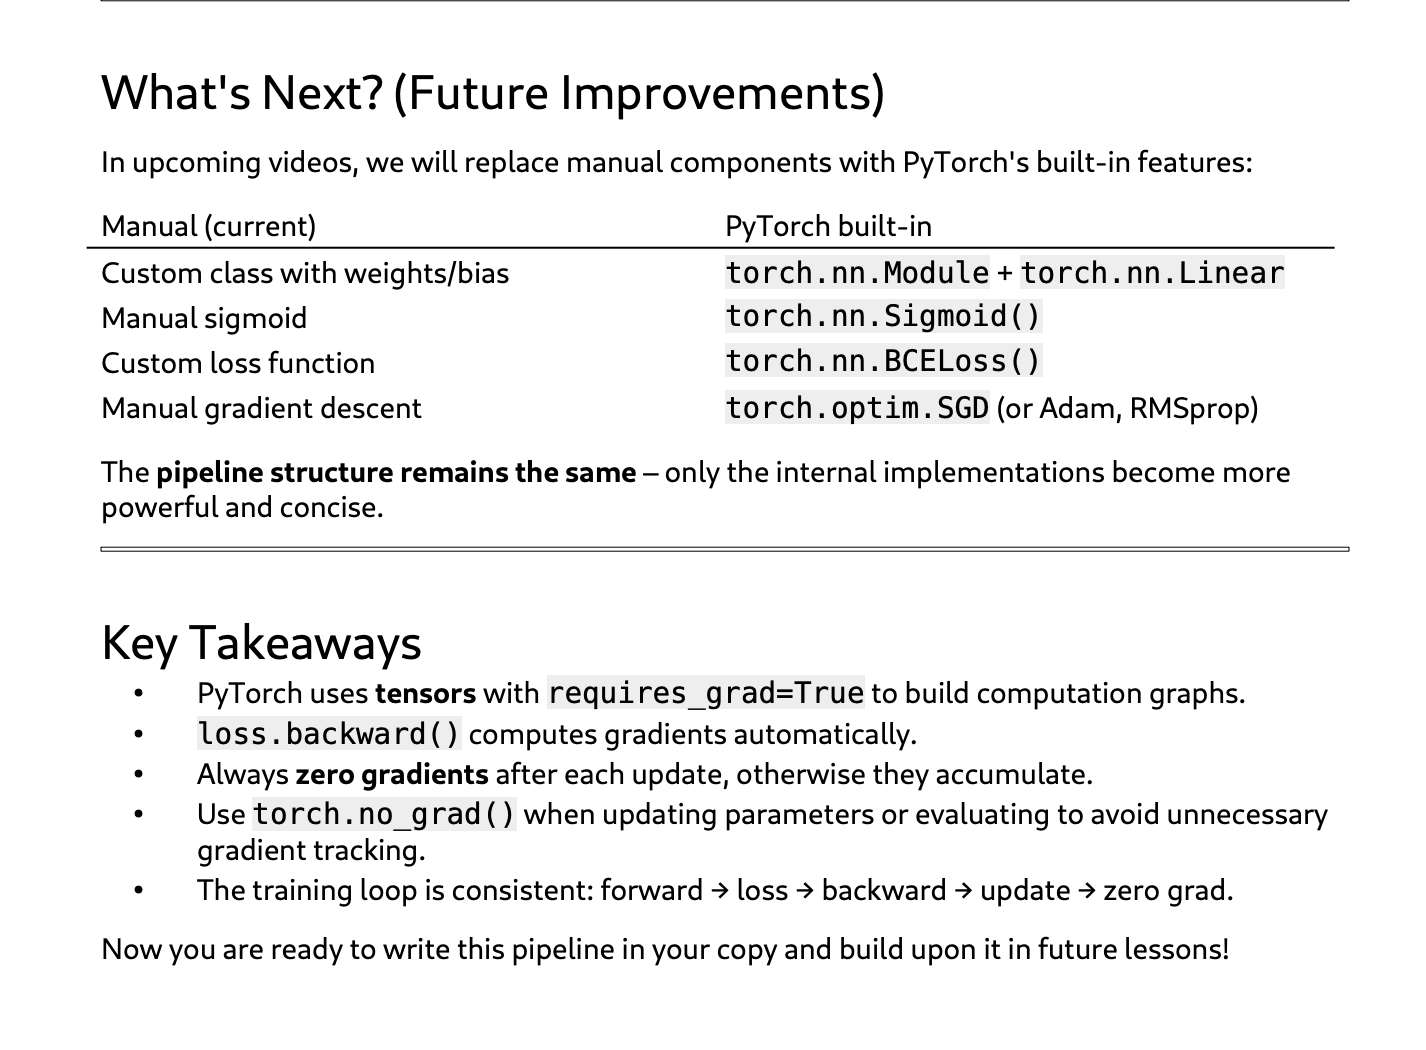

Your explanation is mostly correct and very useful, but there’s one important nuance:

Using `.item()` is **not strictly required to prevent a memory leak**. The real issue is storing tensors that still have attached computation graphs. `.item()` is one way to detach and convert to a Python scalar, but `.detach()` also breaks graph tracking.

Here’s the more precise version:

---

# What `.item()` Does in PyTorch

The `.item()` method extracts a standard Python number from a tensor containing exactly one value.

Example:

```python
import torch

loss = torch.tensor(0.5432)

print(loss)         # tensor(0.5432)
print(loss.item())  # 0.5432
```

It converts:

* PyTorch tensor → Python scalar (`float` or `int`)

---

# Why `.item()` Is Commonly Used

## 1. Logging or Storing Scalar Values

Training losses and metrics are usually scalar tensors:

```python
loss = criterion(outputs, targets)
```

`loss` is still a tensor, so people often do:

```python
losses.append(loss.item())
```

This stores only the numeric value.

---

## 2. Avoiding Graph Retention

This is the important subtlety.

### Problem

If you store tensors directly:

```python
losses.append(loss)
```

and `loss` requires gradients, PyTorch may keep the autograd graph alive because the tensor still references it.

Over many iterations, memory usage can grow significantly.

### Safer Options

```python
losses.append(loss.item())      # Python number
```

or

```python
losses.append(loss.detach())    # Tensor without grad graph
```

`.item()` is popular because metrics/loss histories usually only need plain numbers.

---

# Clean Printing

Without `.item()`:

```python
print(loss)
# tensor(0.5432, grad_fn=<...>)
```

With `.item()`:

```python
print(loss.item())
# 0.5432
```

---

# Important Rule: Tensor Must Have One Element

`.item()` only works for single-element tensors.

Example:

```python
x = torch.tensor([4.5])
print(x.item())   # Works
```

But:

```python
y = torch.tensor([1.0, 2.0, 3.0])
print(y.item())
```

raises:

```python
ValueError: only one element tensors can be converted to Python scalars
```

---

# For Multi-Element Tensors

Use:

```python
y.tolist()
```

or:

```python
y.numpy()
```

(usually after moving to CPU if needed)

```python
y.cpu().numpy()
```

---

# Typical Training Loop Usage

```python
running_loss = 0.0

for inputs, targets in dataloader:
    optimizer.zero_grad()

    outputs = model(inputs)
    loss = criterion(outputs, targets)

    loss.backward()
    optimizer.step()

    running_loss += loss.item()

avg_loss = running_loss / len(dataloader)

print("Average Loss:", avg_loss)
```

This is the standard and memory-safe pattern for tracking training loss.
